# Setup & Installation

In [22]:
import sys
import warnings
warnings.filterwarnings('ignore')

import time, os, re, json
from datetime import datetime
from collections import Counter


print("Installing packages")
!pip install -q wordcloud plotly

print(" Loading libraries.")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import nltk
for pkg in ['stopwords', 'punkt', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from scipy import stats

import networkx as nx

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-darkgrid')
sentiment_analyzer = SentimentIntensityAnalyzer()
START_TIME = time.time()

print(" Setup complete\n")

Installing packages
 Loading libraries.
 Setup complete



# Data Loading

In [23]:
!pip -q install gdown
!gdown --id 1g0RHh2w-9DftxyHcmoFfdiiVKJf-gR06 -O dataset_A.csv

import pandas as pd
df = pd.read_csv("dataset_A.csv")
print(df.shape)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1g0RHh2w-9DftxyHcmoFfdiiVKJf-gR06
To: /content/dataset_A.csv
100% 4.98M/4.98M [00:00<00:00, 70.2MB/s]
(10500, 12)


# Data Preprocessing

In [24]:
required_cols = {
    "date","title","source","number_of_characters_title","number_of_words_title",
    "day_of_week","month","year","quarter","is_weekend","classes_str"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df['date'] = pd.to_datetime(df['date'], errors='coerce')
if df['date'].isna().any():
    bad = df[df['date'].isna()].head(5)
    raise ValueError(f"Some date values could not be parsed. Examples:\n{bad[['date','title']]}")

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df['classes_list'] = df['classes_str'].apply(
    lambda x: [c.strip() for c in str(x).split(';')] if pd.notna(x) and str(x).strip() else []
)

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

df['title_clean'] = df['title'].apply(clean_text)
df = df[df['title_clean'].str.len() > 0].reset_index(drop=True)

print(f"Preprocessed: {len(df):,} headlines\n")

Preprocessed: 10,500 headlines



# Exploratory Analysis

In [25]:
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique sources: {df['source'].nunique():,}")
print(f"Avg words per title: {df['number_of_words_title'].mean():.1f}")

all_classes = [c for classes in df['classes_list'] for c in classes]
print(f"Unique classes: {len(set(all_classes))}")
print(f"Avg classes per headline: {(len(all_classes)/len(df)):.2f}\n")

Date range: 2025-06-14 to 2025-09-11
Unique sources: 3,125
Avg words per title: 14.9
Unique classes: 12
Avg classes per headline: 1.54



# Sentiment Analysis

In [26]:
print(f"Analyzing {len(df):,} headlines")

def analyze_sentiment(text):
    scores = sentiment_analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05: return 'POSITIVE', compound
    elif compound <= -0.05: return 'NEGATIVE', compound
    else: return 'NEUTRAL', compound

results = df['title'].apply(analyze_sentiment)
df['sentiment'] = results.apply(lambda x: x[0])
df['sentiment_score'] = results.apply(lambda x: x[1])

print("\nSentiment Distribution:")
for label, count in df['sentiment'].value_counts().items():
    pct = count/len(df)*100
    print(f"   {label:8s}: {count:6,} ({pct:5.1f}%)")

print(f"\nMean sentiment: {df['sentiment_score'].mean():+.3f}\n")

Analyzing 10,500 headlines

Sentiment Distribution:
   POSITIVE:  4,753 ( 45.3%)
   NEUTRAL :  3,738 ( 35.6%)
   NEGATIVE:  2,009 ( 19.1%)

Mean sentiment: +0.136



# Behavioral Influence Score (BIS)

In [27]:
def zscore(s):
    s = s.astype(float)
    mu = s.mean()
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return s * 0.0
    return (s - mu) / sd

def punct_density(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    punct = re.findall(r"[!?.,;:\-\"()]", text)
    return len(punct) / max(1, len(text))

def avg_word_len(text_clean):
    if not isinstance(text_clean, str) or len(text_clean.strip()) == 0:
        return 0.0
    toks = text_clean.split()
    if len(toks) == 0:
        return 0.0
    return float(np.mean([len(t) for t in toks]))

HUMAN_AGENCY = set("""
human humans people person worker workers employee employees student students teacher teachers doctor doctors patient patients
creator creators artist artists writer writers designer designers user users community communities family families parent parents
learn learning decide decision choose choice control controlled empower empowering assist help guide guidance collaborate
""".split())

AI_DOMINANCE = set("""
replace replacing replacement automate automated automation takeover dominate dominated displace displaced displacement
layoff layoffs firing jobcut jobcuts surveillance monitor monitoring manipulate manipulated manipulation exploit exploited
bias biased risk risky threat threats danger anxiety fear panic
""".split())

def agency_balance_from_clean(text_clean):
    if not isinstance(text_clean, str) or len(text_clean.strip()) == 0:
        return 0, 0, 0
    toks = text_clean.split()
    h = sum(1 for t in toks if t in HUMAN_AGENCY)
    a = sum(1 for t in toks if t in AI_DOMINANCE)
    return (h - a), h, a

CLASS_WEIGHTS = {
    "Work, Jobs & Economy": 0.30,
    "Society, Ethics & Culture": 0.30,
    "Health, Safety & Risk": 0.25,
    "Cognitive & Decision-Making": 0.20,
    "Emotion, Motivation & Well-being": 0.20,
    "Social Interaction & Relationships": 0.15,
    "Creativity, Expression & Identity": 0.10,
    "Routine, Lifestyle & Behavior": 0.10,
    "Learning, Knowledge & Education": 0.10,
    "Technology & Interaction": 0.05,
    "Sentiment (Positive / Negative Feelings)": 0.05,
    "Human Roles": 0.05,
}

def class_weight_from_list(classes_list):
    if not isinstance(classes_list, list) or len(classes_list) == 0:
        return 0.0
    return float(sum(CLASS_WEIGHTS.get(c, 0.0) for c in classes_list))

print("Computing BIS features")

df["sent_intensity"] = df["sentiment_score"].abs()
df["punct_density"] = df["title"].apply(punct_density)
df["avg_word_len"] = df["title_clean"].apply(avg_word_len)

df["word_count"] = df["number_of_words_title"]
fallback_wc = df["title_clean"].str.split().str.len()
df["word_count"] = df["word_count"].fillna(fallback_wc).astype(int)

df["cog_load"] = (0.60 * df["word_count"]) + (0.25 * df["avg_word_len"] * 2.0) + (0.15 * df["punct_density"] * 100.0)

ag_data = df["title_clean"].apply(agency_balance_from_clean)
df["agency_balance"] = ag_data.apply(lambda x: x[0])
df["human_hits"] = ag_data.apply(lambda x: x[1])
df["ai_hits"] = ag_data.apply(lambda x: x[2])

df["class_weight"] = df["classes_list"].apply(class_weight_from_list)

df["Z_emotion"] = zscore(df["sent_intensity"])
df["Z_cog"] = zscore(df["cog_load"])
df["Z_agency"] = zscore(df["agency_balance"])
df["Z_sentint"] = zscore(df["sent_intensity"])

df["BIS"] = (
    0.35 * df["Z_emotion"] +
    0.25 * df["Z_cog"] +
    0.25 * df["Z_sentint"] +
    0.15 * df["Z_agency"]
)

df["BIS_weighted"] = df["BIS"] * (1.0 + df["class_weight"])

print("BIS computed")
print(f"   BIS_weighted mean: {df['BIS_weighted'].mean():+.3f}")
print(f"   BIS_weighted std : {df['BIS_weighted'].std(ddof=0):.3f}\n")

Computing BIS features
BIS computed
   BIS_weighted mean: +0.010
   BIS_weighted std : 0.906



# Visualization 1 - Overview

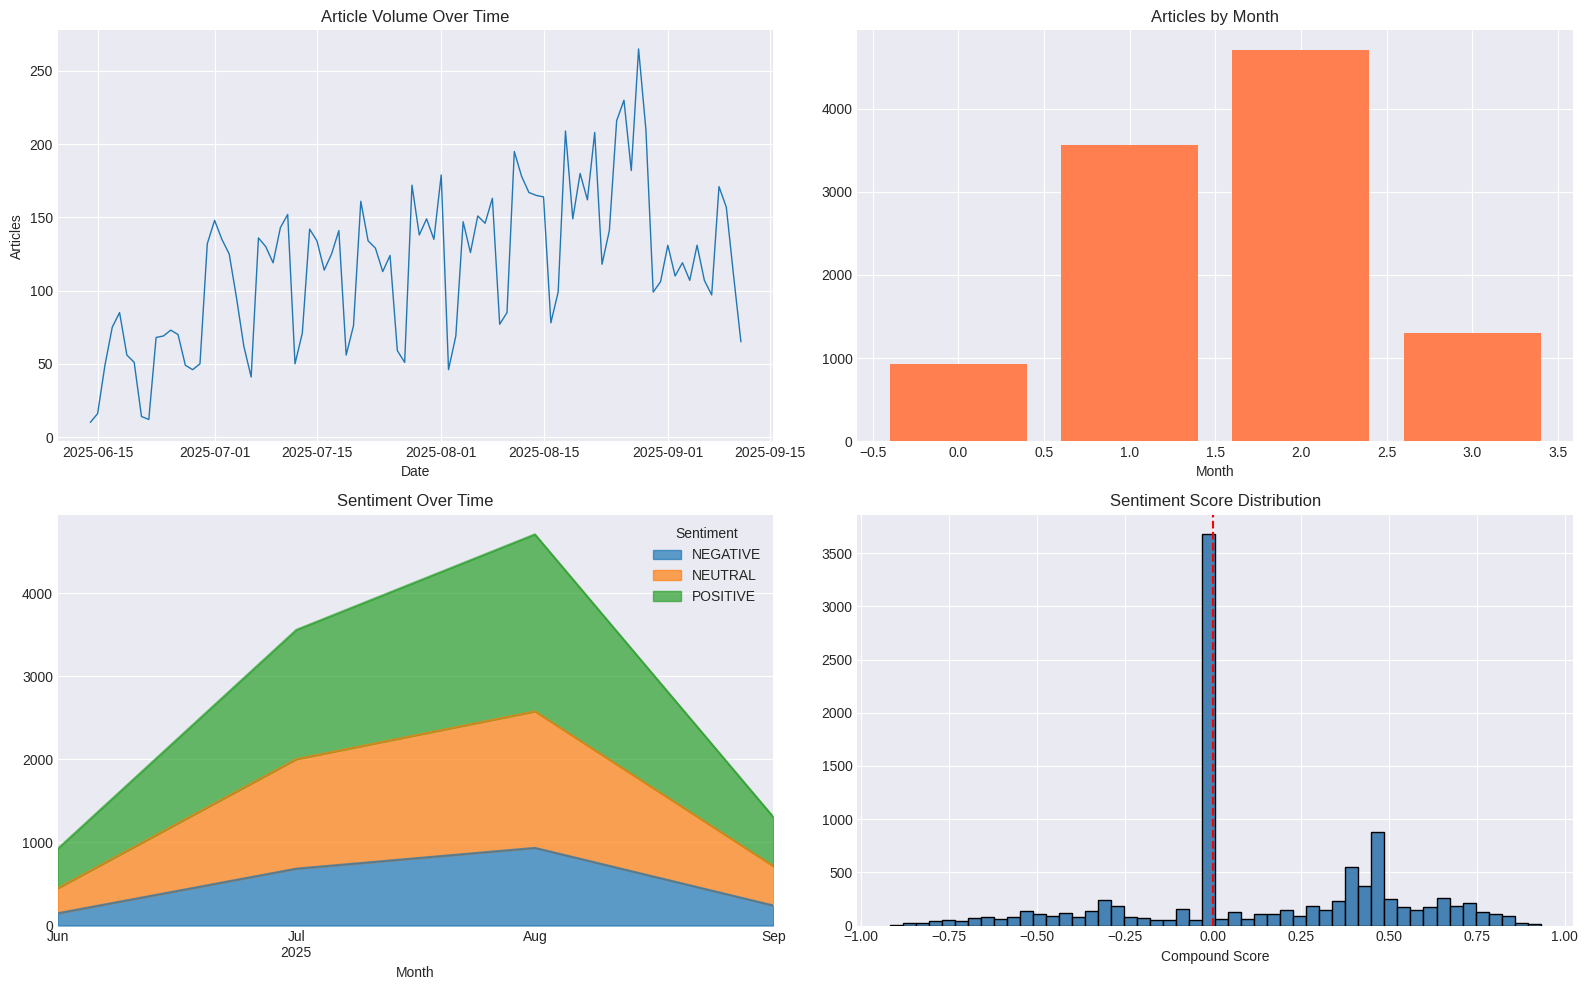

Saved: analysis_overview.png



In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

daily = df.groupby('date').size()
axes[0,0].plot(daily.index, daily.values, linewidth=1)
axes[0,0].set_title('Article Volume Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Articles')

monthly = df.groupby(df['date'].dt.to_period('M')).size()
axes[0,1].bar(range(len(monthly)), monthly.values, color='coral')
axes[0,1].set_title('Articles by Month')
axes[0,1].set_xlabel('Month')

sent_time = df.groupby([df['date'].dt.to_period('M'), 'sentiment']).size().unstack(fill_value=0)
sent_time.plot(kind='area', stacked=True, ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('Sentiment Over Time')
axes[1,0].set_xlabel('Month')
axes[1,0].legend(title='Sentiment')

axes[1,1].hist(df['sentiment_score'], bins=50, color='steelblue', edgecolor='black')
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].set_title('Sentiment Score Distribution')
axes[1,1].set_xlabel('Compound Score')

plt.tight_layout()
plt.savefig('analysis_overview.png', dpi=300)
plt.show()
print("Saved: analysis_overview.png\n")

# Visualization 2 - Word Cloud

Generating word cloud


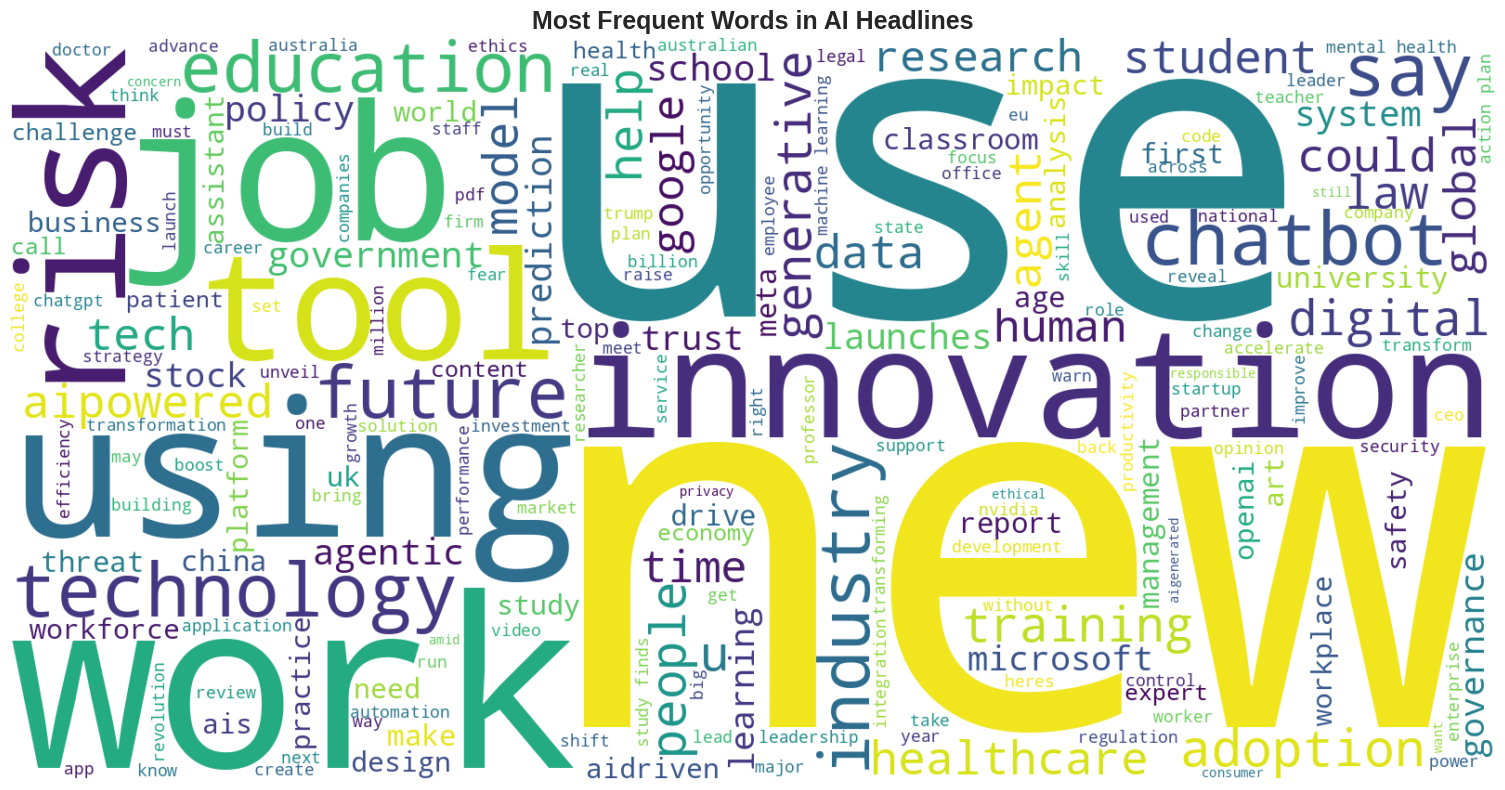

Saved: wordcloud.png



In [29]:
print("Generating word cloud")
all_text = ' '.join(df['title_clean'])
stop_words = set(stopwords.words('english'))
stop_words.update(['ai', 'artificial', 'intelligence'])

wc = WordCloud(width=1600, height=800, background_color='white',
               stopwords=stop_words, max_words=200, colormap='viridis')
wc.generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in AI Headlines', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=300)
plt.show()
print("Saved: wordcloud.png\n")

# Visualization 3 - Top Sources

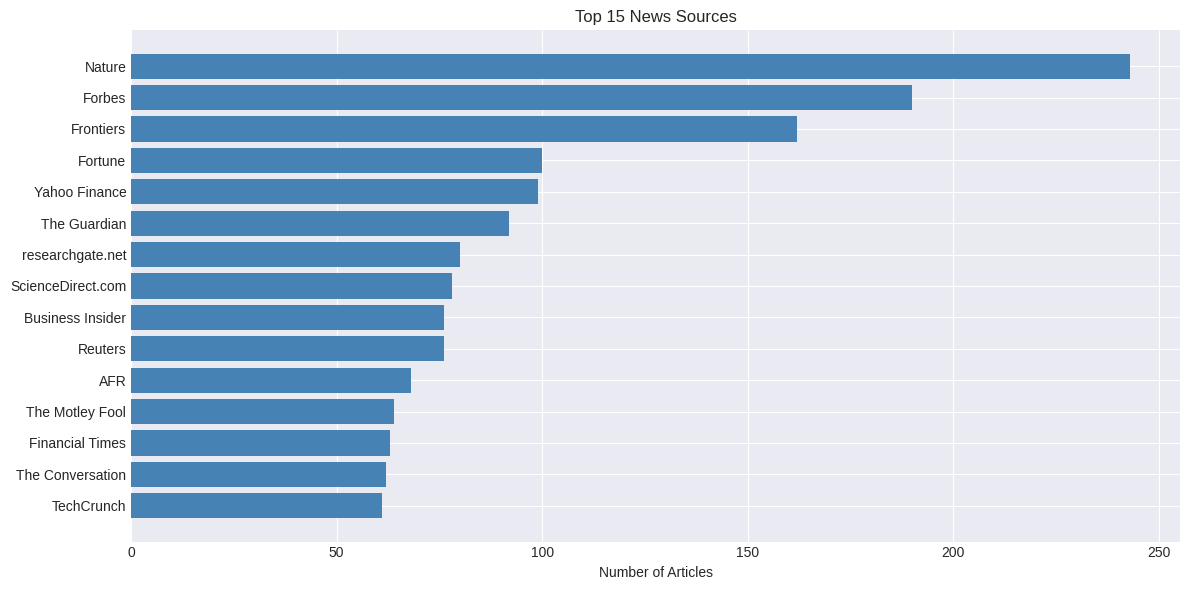

Saved: top_sources.png



In [30]:
top_sources = df['source'].value_counts().head(15)
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_sources)), top_sources.values, color='steelblue')
plt.yticks(range(len(top_sources)), top_sources.index)
plt.gca().invert_yaxis()
plt.xlabel('Number of Articles')
plt.title('Top 15 News Sources')
plt.tight_layout()
plt.savefig('top_sources.png', dpi=300)
plt.show()
print("Saved: top_sources.png\n")

# Visualization 4 - BIS Weekly Trend

BIS: Weekly trend


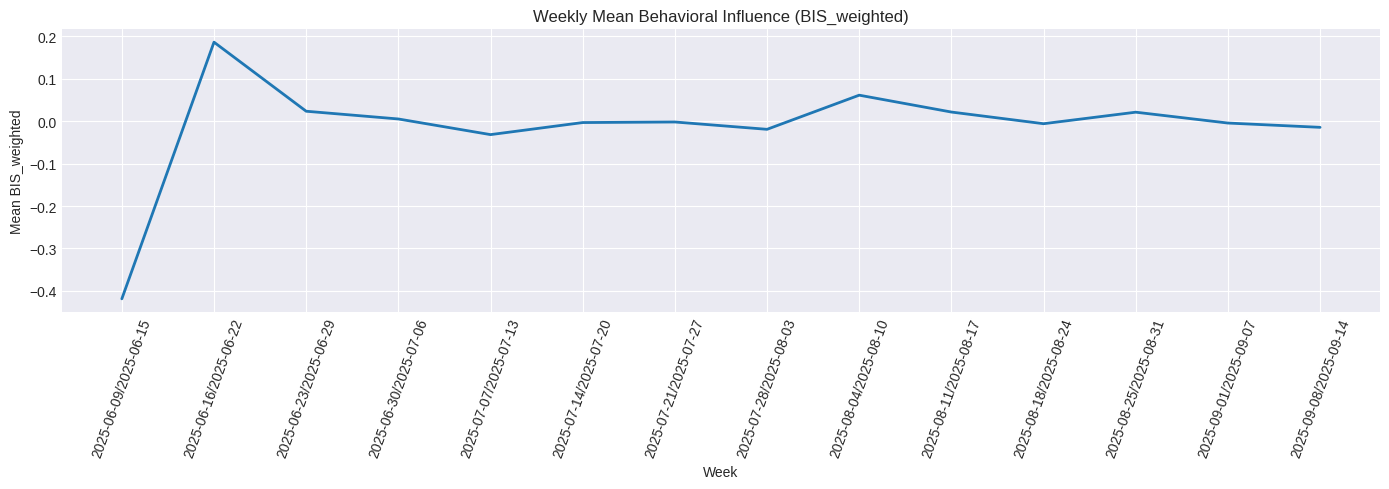

Saved: bis_weekly_trend.png



In [31]:
print("BIS: Weekly trend")
df["week"] = df["date"].dt.to_period("W").astype(str)
weekly_bis = df.groupby("week")["BIS_weighted"].mean().reset_index()

plt.figure(figsize=(14,5))
plt.plot(weekly_bis["week"], weekly_bis["BIS_weighted"], linewidth=2)
plt.xticks(rotation=70)
plt.title("Weekly Mean Behavioral Influence (BIS_weighted)")
plt.xlabel("Week")
plt.ylabel("Mean BIS_weighted")
plt.tight_layout()
plt.savefig("bis_weekly_trend.png", dpi=300)
plt.show()
print("Saved: bis_weekly_trend.png\n")

# Visualization 5 - BIS by Class

BIS: by class


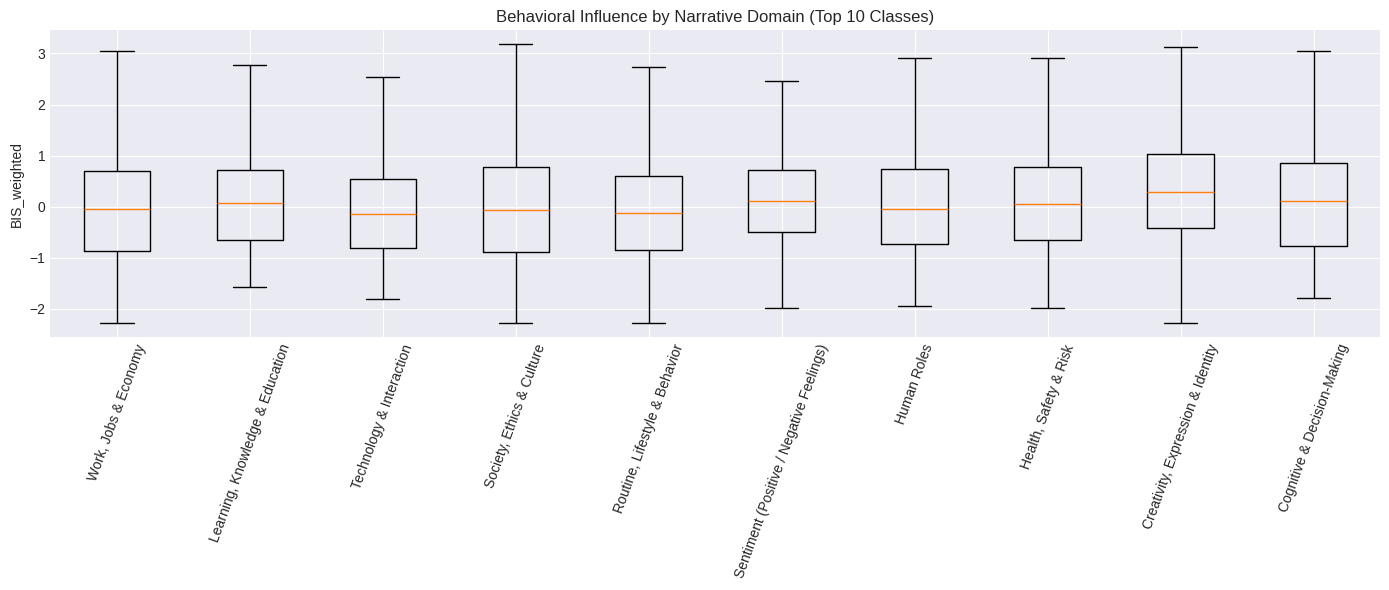

Saved: bis_by_class.png



In [32]:
print("BIS: by class")
tmp = df.explode("classes_list")
tmp = tmp[tmp["classes_list"].notna() & (tmp["classes_list"] != "")]
top10 = tmp["classes_list"].value_counts().head(10).index.tolist()

plt.figure(figsize=(14,6))
data = [tmp.loc[tmp["classes_list"]==c, "BIS_weighted"].values for c in top10]
plt.boxplot(data, labels=top10, showfliers=False)
plt.xticks(rotation=70)
plt.title("Behavioral Influence by Narrative Domain (Top 10 Classes)")
plt.ylabel("BIS_weighted")
plt.tight_layout()
plt.savefig("bis_by_class.png", dpi=300)
plt.show()
print("Saved: bis_by_class.png\n")

# Visualization 6 - BIS by Source

BIS: top sources by influence


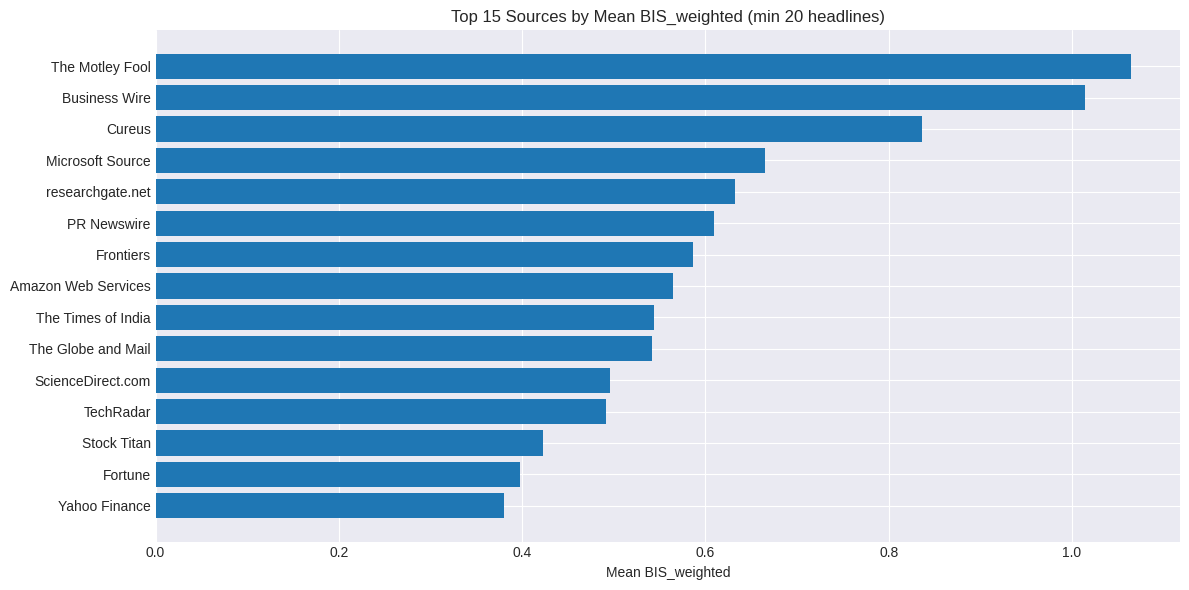

Saved: top_sources_by_bis.png



In [33]:
print("BIS: top sources by influence")
src_bis = df.groupby("source").agg(n=("title","count"), mean_bis=("BIS_weighted","mean")).reset_index()
src_bis = src_bis[src_bis["n"] >= 20].sort_values("mean_bis", ascending=False).head(15)

plt.figure(figsize=(12,6))
plt.barh(range(len(src_bis)), src_bis["mean_bis"].values)
plt.yticks(range(len(src_bis)), src_bis["source"])
plt.gca().invert_yaxis()
plt.xlabel("Mean BIS_weighted")
plt.title("Top 15 Sources by Mean BIS_weighted (min 20 headlines)")
plt.tight_layout()
plt.savefig("top_sources_by_bis.png", dpi=300)
plt.show()
print("Saved: top_sources_by_bis.png\n")

# Visualization 7 - Agency vs Emotion

BIS: agency vs emotion scatter


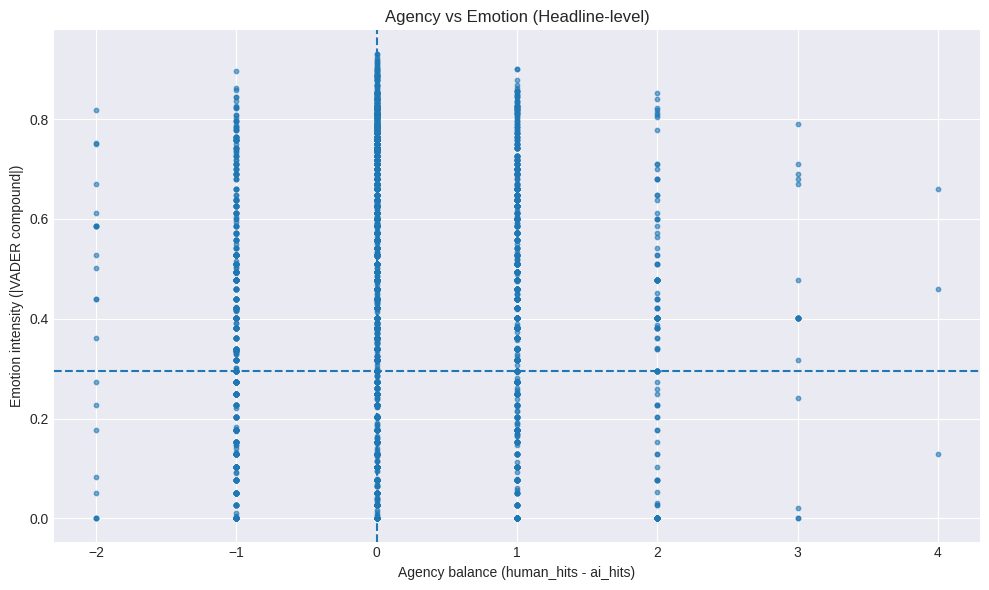

Saved: agency_vs_emotion.png



In [34]:
print("BIS: agency vs emotion scatter")
plt.figure(figsize=(10,6))
plt.scatter(df["agency_balance"], df["sent_intensity"], s=10, alpha=0.6)
plt.axvline(0, linestyle="--")
plt.axhline(df["sent_intensity"].median(), linestyle="--")
plt.title("Agency vs Emotion (Headline-level)")
plt.xlabel("Agency balance (human_hits - ai_hits)")
plt.ylabel("Emotion intensity (|VADER compound|)")
plt.tight_layout()
plt.savefig("agency_vs_emotion.png", dpi=300)
plt.show()
print("Saved: agency_vs_emotion.png\n")

# Topic Modeling (LDA)

In [35]:
print("Running Latent Dirichlet Allocation (LDA)")

vectorizer = CountVectorizer(max_features=1000, stop_words='english',
                             min_df=5, max_df=0.7)
doc_term_matrix = vectorizer.fit_transform(df['title_clean'])

n_topics = 10
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=RANDOM_SEED,
    max_iter=20,
    n_jobs=-1
)
lda.fit(doc_term_matrix)

feature_names = vectorizer.get_feature_names_out()
print(f"\nDiscovered {n_topics} Topics:\n")
for idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {idx+1:2d}: {', '.join(top_words)}")

print("\nTopic modeling complete\n")

Running Latent Dirichlet Allocation (LDA)

Discovered 10 Topics:

Topic  1: innovation, data, agentic, launches, management, global, openai, drive, platform, design
Topic  2: artificial, intelligence, learning, healthcare, using, prediction, stock, practice, machine, analysis
Topic  3: technology, law, workplace, new, assistant, world, era, agents, model, collaboration
Topic  4: health, chatbot, content, mental, social, media, aigenerated, growth, experts, care
Topic  5: job, study, use, students, finds, school, market, work, chatbots, new
Topic  6: work, says, governance, new, workforce, amazon, staff, ceo, microsoft, help
Topic  7: future, education, digital, human, age, ais, threat, aipowered, time, generative
Topic  8: government, training, trust, people, productivity, adoption, big, tech, warns, says
Topic  9: industry, new, jobs, automation, risk, safety, report, uk, major, shift
Topic 10: intelligence, artificial, policy, university, plan, action, education, pdf, technology, use

# Class Analysis

  Class Distribution:
   Work, Jobs & Economy                               2,526 (15.6%)
   Learning, Knowledge & Education                    1,946 (12.0%)
   Technology & Interaction                           1,733 (10.7%)
   Society, Ethics & Culture                          1,584 ( 9.8%)
   Routine, Lifestyle & Behavior                      1,479 ( 9.1%)
   Sentiment (Positive / Negative Feelings)           1,441 ( 8.9%)
   Human Roles                                        1,256 ( 7.8%)
   Health, Safety & Risk                              1,230 ( 7.6%)
   Creativity, Expression & Identity                    877 ( 5.4%)
   Cognitive & Decision-Making                          832 ( 5.1%)
   Social Interaction & Relationships                   730 ( 4.5%)
   Emotion, Motivation & Well-being                     551 ( 3.4%)


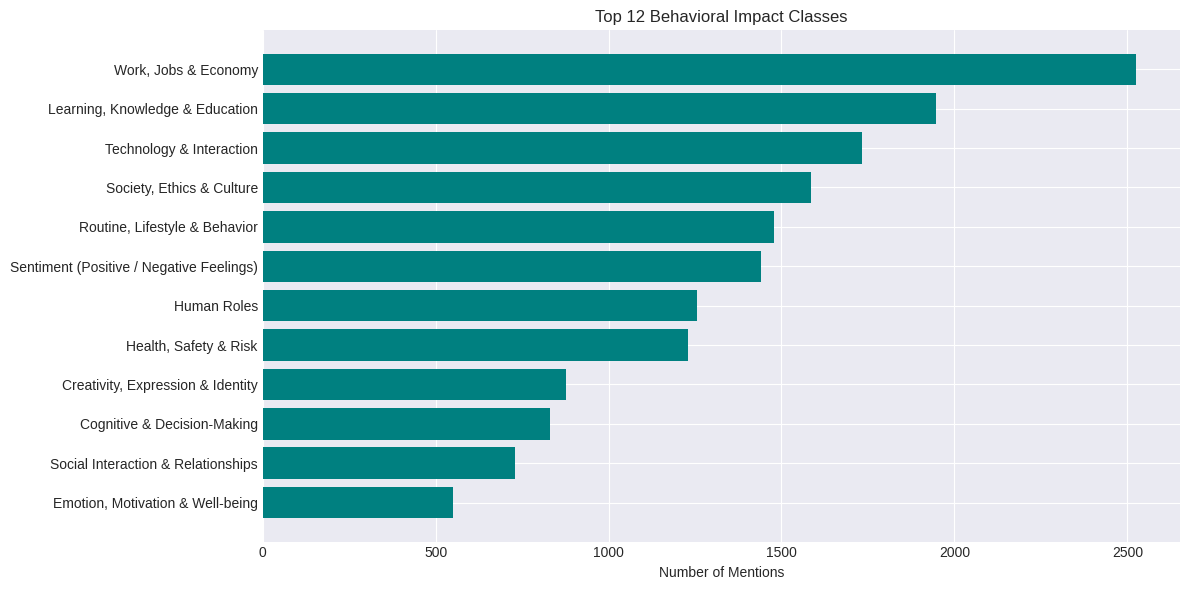


 Saved: class_distribution.png



In [36]:
class_counts = Counter(all_classes)
print("  Class Distribution:")
for cls, count in class_counts.most_common(12):
    pct = count/len(all_classes)*100 if len(all_classes) else 0
    print(f"   {cls:50s} {count:5,} ({pct:4.1f}%)")

top_classes = pd.Series(class_counts).nlargest(12)
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_classes)), top_classes.values, color='teal')
plt.yticks(range(len(top_classes)), top_classes.index)
plt.gca().invert_yaxis()
plt.xlabel('Number of Mentions')
plt.title('Top 12 Behavioral Impact Classes')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()
print("\n Saved: class_distribution.png\n")

# Statistical Tests

In [37]:
weekend = df[df['is_weekend']]['sentiment_score']
weekday = df[~df['is_weekend']]['sentiment_score']
stat, p_value = stats.mannwhitneyu(weekend, weekday)
print(f" Weekend vs Weekday Sentiment:")
print(f"   Mann-Whitney U: {stat:.2f}, p-value: {p_value:.4f}")
print("    Significant difference detected!" if p_value < 0.05 else "     No significant difference")

weekend_b = df[df['is_weekend']]['BIS_weighted']
weekday_b = df[~df['is_weekend']]['BIS_weighted']
stat_b, p_value_b = stats.mannwhitneyu(weekend_b, weekday_b)
print(f"\n Weekend vs Weekday BIS_weighted:")
print(f"   Mann-Whitney U: {stat_b:.2f}, p-value: {p_value_b:.4f}")
print("    Significant difference detected!" if p_value_b < 0.05 else "     No significant difference")

print(f"\n Sentiment by Class (Top 5):")
top_5_classes = [cls for cls, _ in class_counts.most_common(5)]
for cls in top_5_classes:
    mask = df['classes_list'].apply(lambda x: cls in x)
    if mask.sum() > 0:
        avg_sent = df[mask]['sentiment_score'].mean()
        print(f"   {cls:40s} {avg_sent:+.3f}")

print("\n Statistical tests complete\n")

 Weekend vs Weekday Sentiment:
   Mann-Whitney U: 7369435.50, p-value: 0.0353
    Significant difference detected!

 Weekend vs Weekday BIS_weighted:
   Mann-Whitney U: 7712118.00, p-value: 0.3630
     No significant difference

 Sentiment by Class (Top 5):
   Work, Jobs & Economy                     +0.169
   Learning, Knowledge & Education          +0.158
   Technology & Interaction                 +0.133
   Society, Ethics & Culture                +0.139
   Routine, Lifestyle & Behavior            +0.183

 Statistical tests complete



# Key Insights & Summary

In [38]:
total_headlines = len(df)
time_span = max(1, (df['date'].max() - df['date'].min()).days)
avg_per_day = total_headlines / time_span

pos_pct = (df['sentiment'] == 'POSITIVE').mean() * 100
neg_pct = (df['sentiment'] == 'NEGATIVE').mean() * 100

growth_rate = (monthly.iloc[-3:].mean() / monthly.iloc[:3].mean() - 1) * 100 if len(monthly) > 6 else 0

print(" BIS INSIGHTS (What judges care about):")

top_bis = df.sort_values("BIS_weighted", ascending=False).head(8)[
    ["date","source","title","BIS_weighted","classes_str"]
]
print("\n Top 8 Highest BIS_weighted Headlines (Most behavior-influential framing):")
display(top_bis)

tmp2 = df.explode("classes_list")
tmp2 = tmp2[tmp2["classes_list"].notna() & (tmp2["classes_list"] != "")]
class_bis = tmp2.groupby("classes_list")["BIS_weighted"].mean().sort_values(ascending=False).head(8)

print("\n Classes with Highest Average BIS_weighted:")
for cls, v in class_bis.items():
    print(f"   {cls:50s} {v:+.3f}")

pct_ai_dominant = (df["agency_balance"] < 0).mean() * 100
pct_human_agency = (df["agency_balance"] > 0).mean() * 100
print(f"\n Agency framing split:")
print(f"   Human-leaning headlines: {pct_human_agency:.1f}%")
print(f"   AI-dominant/displacing: {pct_ai_dominant:.1f}%\n")

print(f" KEY FINDING #1: Coverage Growth")
print(f"   AI news coverage {'increased' if growth_rate > 0 else 'decreased'} by {abs(growth_rate):.1f}%")
print(f"   from early period to recent months\n")

print(f" KEY FINDING #2: Sentiment Patterns")
overall_tone = "Optimistic" if df['sentiment_score'].mean() > 0.05 else ("Cautious" if df['sentiment_score'].mean() > -0.05 else "Concerned")
print(f"   {pos_pct:.1f}% positive, {neg_pct:.1f}% negative")
print(f"   Overall tone: {overall_tone}\n")

print(f" KEY FINDING #3: Behavioral Focus")
top_class = class_counts.most_common(1)[0] if class_counts else ("N/A", 0)
print(f"   Most discussed: {top_class[0]} ({top_class[1]:,} mentions)")
print(f"   Media emphasizes: {', '.join([c for c, _ in class_counts.most_common(3)])}\n")

 BIS INSIGHTS (What judges care about):

 Top 8 Highest BIS_weighted Headlines (Most behavior-influential framing):


,date,source,title,BIS_weighted,classes_str
3898,2025-08-16,Facebook,Many ChatGPT users were upset when an older ve...,4.943574,Human Roles; Social Interaction & Relationship...
3490,2025-08-19,International Business Times,Artificial Intelligence Integration in Healthc...,4.433619,"Routine, Lifestyle & Behavior; Work, Jobs & Ec..."
3955,2025-08-16,Facebook,The blunder in the Supreme Court of Victoria s...,4.322754,"Creativity, Expression & Identity; Society, Et..."
8399,2025-07-11,Travel And Tour World,How Can the Synergy Between Social Media and A...,4.249325,"Emotion, Motivation & Well-being; Cognitive & ..."
3564,2025-08-19,Facebook,As artificial intelligence becomes more integr...,4.235659,"Routine, Lifestyle & Behavior; Health, Safety ..."
7034,2025-07-23,Facebook,More Filipinos are increasingly turning to gen...,4.120451,"Routine, Lifestyle & Behavior; Social Interact..."
5822,2025-08-02,Nature,AI language and emotional support as a physici...,3.936457,Sentiment (Positive / Negative Feelings); Cogn...
5117,2025-08-08,moda — 數位發展部,Inauguration of Taiwan Artificial Intelligence...,3.759550,"Work, Jobs & Economy; Society, Ethics & Cultur..."



 Classes with Highest Average BIS_weighted:
   Emotion, Motivation & Well-being                   +0.341
   Creativity, Expression & Identity                  +0.336
   Sentiment (Positive / Negative Feelings)           +0.150
   Cognitive & Decision-Making                        +0.136
   Social Interaction & Relationships                 +0.129
   Health, Safety & Risk                              +0.119
   Learning, Knowledge & Education                    +0.110
   Human Roles                                        +0.077

 Agency framing split:
   Human-leaning headlines: 16.9%
   AI-dominant/displacing: 7.1%

 KEY FINDING #1: Coverage Growth
   AI news coverage decreased by 0.0%
   from early period to recent months

 KEY FINDING #2: Sentiment Patterns
   45.3% positive, 19.1% negative
   Overall tone: Optimistic

 KEY FINDING #3: Behavioral Focus
   Most discussed: Work, Jobs & Economy (2,526 mentions)
   Media emphasizes: Work, Jobs & Economy, Learning, Knowledge & Education, 

# Export Results

In [39]:
summary = {
    'total_headlines': int(total_headlines),
    'date_range': f"{df['date'].min().date()} to {df['date'].max().date()}",
    'unique_sources': int(df['source'].nunique()),
    'avg_sentiment': float(df['sentiment_score'].mean()),
    'positive_pct': float(pos_pct),
    'negative_pct': float(neg_pct),
    'top_class': top_class[0],
    'top_source': str(df['source'].value_counts().index[0]),
    'avg_BIS_weighted': float(df['BIS_weighted'].mean()),
    'agency_human_pct': float(pct_human_agency),
    'agency_ai_pct': float(pct_ai_dominant),
}

with open('analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

df_export = df[['date', 'title', 'source', 'sentiment', 'sentiment_score',
                'BIS', 'BIS_weighted', 'agency_balance', 'class_weight', 'classes_str']]
df_export.to_csv('analysis_results.csv', index=False)

print(" Saved: analysis_summary.json")
print(" Saved: analysis_results.csv")
print(" Saved: analysis_overview.png, wordcloud.png, top_sources.png")
print(" Saved: bis_weekly_trend.png, bis_by_class.png, top_sources_by_bis.png, agency_vs_emotion.png")
print(" Saved: class_distribution.png\n")

 Saved: analysis_summary.json
 Saved: analysis_results.csv
 Saved: analysis_overview.png, wordcloud.png, top_sources.png
 Saved: bis_weekly_trend.png, bis_by_class.png, top_sources_by_bis.png, agency_vs_emotion.png
 Saved: class_distribution.png



# Completion

In [40]:
total_time = (time.time() - START_TIME) / 60
print(" ANALYSIS COMPLETE")
print(f"\n  Total runtime: {total_time:.1f} minutes")
print(f" Analyzed {total_headlines:,} AI headlines")


 ANALYSIS COMPLETE

  Total runtime: 1.0 minutes
 Analyzed 10,500 AI headlines
